# Atividade — Transformações geométricas em 2D

As escalas e rotações são feitas em relação à **origem (0, 0)**.
Cada exercício começa com as coordenadas de seu enunciado: no exercício 3, usei o triângulo original do exercício 2.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mostra os resultados com até quatro casas decimais.
np.set_printoptions(precision=4, suppress=True)

# Função usada apenas para desenhar os pontos e as figuras.
def plotar(original, transformado, nomes, titulo):
    plt.figure(figsize=(6, 6))
    for pontos, cor, legenda, sufixo in [
        (original, 'tab:blue', 'Original', ''),
        (transformado, 'tab:orange', 'Transformado', "'"),
    ]:
        pontos = np.array(pontos)
        contorno = pontos
        if len(pontos) > 1:
            contorno = np.vstack([pontos, pontos[0]])  # Fecha o polígono.
        plt.plot(contorno[:, 0], contorno[:, 1], 'o-', color=cor, label=legenda)
        for nome, (x, y) in zip(nomes, pontos):
            plt.annotate(nome + sufixo, (x, y), xytext=(5, 5), textcoords='offset points')
    plt.axhline(0, color='gray', linewidth=0.8)
    plt.axvline(0, color='gray', linewidth=0.8)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(titulo)
    plt.axis('equal')  # Mesma escala visual nos dois eixos.
    plt.margins(0.2)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## Exercício 1 — Translação simples

Dado o ponto P(2, 3), aplique a translação com vetor (4, −2).

**Perguntas:** Qual é o novo ponto P'? Quais coordenadas foram alteradas?

Somamos o vetor de translação ao ponto: (x', y') = (x + 4, y − 2).

P' = [6 1]


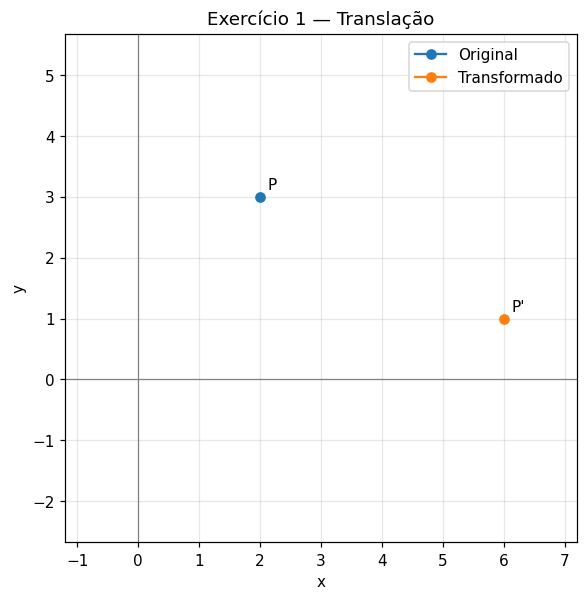

In [ ]:
p = np.array([2, 3])
vetor = np.array([4, -2])
p_novo = p + vetor

print("P' =", p_novo)
plotar([p], [p_novo], ['P'], 'Exercício 1 — Translação')

**Resposta:** P' = **(6, 1)**. As duas coordenadas foram alteradas: x passou de 2 para 6 e y passou de 3 para 1.

## Exercício 2 — Escala uniforme

Considere o triângulo A(1, 1), B(3, 1) e C(2, 4). Aplique uma escala uniforme de fator 2.

**Perguntas:** Quais são as novas coordenadas dos vértices? O que acontece com o tamanho do triângulo?

Multiplicamos as duas coordenadas de cada vértice por 2.

A', B', C' (uma linha por vértice):
[[2 2]
 [6 2]
 [4 8]]


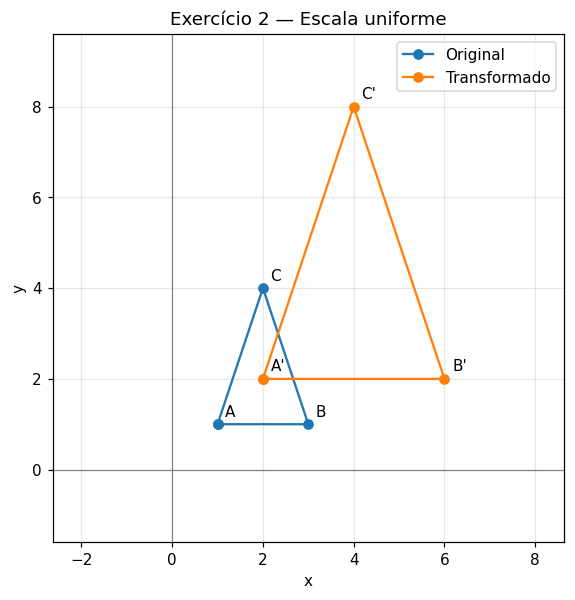

In [ ]:
triangulo = np.array([[1, 1], [3, 1], [2, 4]])
triangulo_novo = triangulo * 2

print("A', B', C' (uma linha por vértice):")
print(triangulo_novo)
plotar(triangulo, triangulo_novo, ['A', 'B', 'C'], 'Exercício 2 — Escala uniforme')

**Resposta:** A' = **(2, 2)**, B' = **(6, 2)** e C' = **(4, 8)**.
Os comprimentos dos lados e a altura dobram, mantendo a forma do triângulo. A área fica quatro vezes maior, passando de 3 para 12 unidades quadradas.

## Exercício 3 — Escala não uniforme

Aplique uma escala não uniforme no triângulo original do exercício 2, com fator 2 no eixo x e fator 0,5 no eixo y.

**Pergunta:** Quais são as novas coordenadas dos vértices?

Usamos (x', y') = (2x, 0,5y).

A', B', C' (uma linha por vértice):
[[2.  0.5]
 [6.  0.5]
 [4.  2. ]]


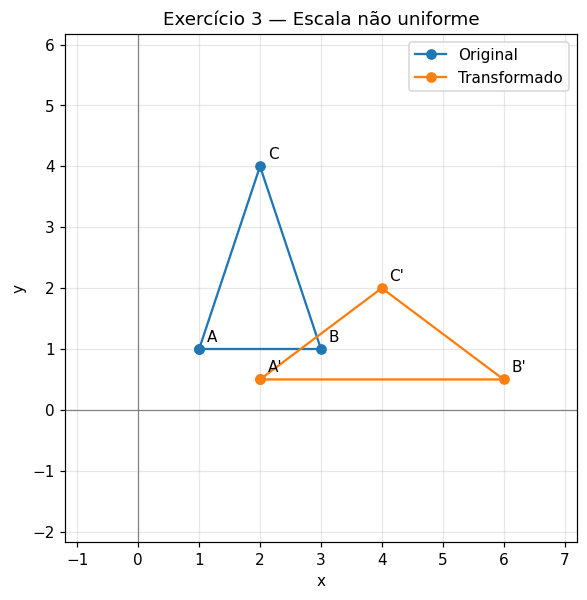

In [4]:
triangulo = np.array([[1, 1], [3, 1], [2, 4]])
fatores = np.array([2, 0.5])
triangulo_novo = triangulo * fatores

print("A', B', C' (uma linha por vértice):")
print(triangulo_novo)
plotar(triangulo, triangulo_novo, ['A', 'B', 'C'], 'Exercício 3 — Escala não uniforme')

**Resposta:** A' = **(2; 0,5)**, B' = **(6; 0,5)** e C' = **(4; 2)**.
A largura dobra e a altura cai pela metade. O ponto e vírgula separa as coordenadas quando usamos vírgula decimal.

## Exercício 4 — Rotação em torno da origem

Rotacione o ponto P(1, 0) em 90° no sentido anti-horário em torno da origem.

**Pergunta:** Qual é a nova posição de P'?

A matriz de rotação é construída com seno e cosseno. O símbolo `@` faz a multiplicação matricial; um ângulo positivo indica o sentido anti-horário.

P' = [0. 1.]


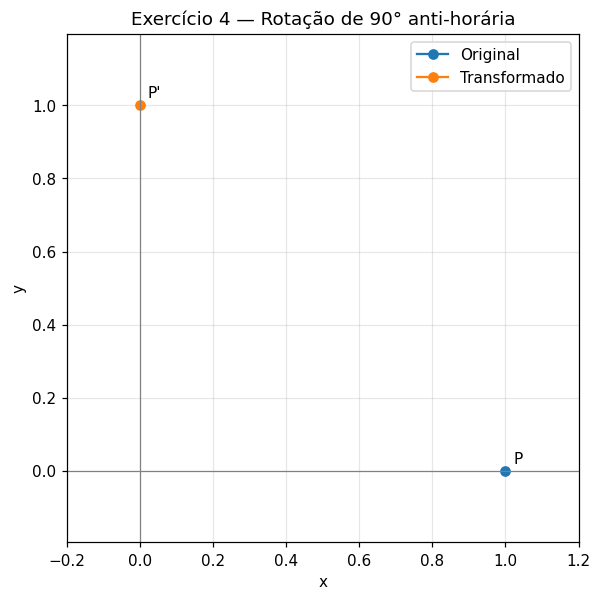

In [5]:
p = np.array([1, 0])
angulo = np.deg2rad(90)  # NumPy usa ângulos em radianos.
rotacao = np.array([
    [np.cos(angulo), -np.sin(angulo)],
    [np.sin(angulo),  np.cos(angulo)],
])
p_novo = rotacao @ p

print("P' =", p_novo)
plotar([p], [p_novo], ['P'], 'Exercício 4 — Rotação de 90° anti-horária')

**Resposta:** P' = **(0, 1)**. Na rotação de 90° anti-horária, (x, y) passa a (−y, x).
O cálculo com seno e cosseno pode produzir um valor muito próximo de zero, exibido como zero por causa do arredondamento.

## Exercício 5 — Rotação de um polígono

Um quadrado tem vértices A(1, 1), B(1, 4), C(4, 4) e D(4, 1). Aplique uma rotação de 45° no sentido horário em torno da origem.

**Pergunta:** Quais são as novas coordenadas dos vértices?

Usei −45° para indicar o sentido horário. Como cada vértice está em uma linha, multiplicamos pela matriz de rotação transposta (`rotacao.T`).

A', B', C', D' (uma linha por vértice):
[[ 1.4142  0.    ]
 [ 3.5355  2.1213]
 [ 5.6569  0.    ]
 [ 3.5355 -2.1213]]


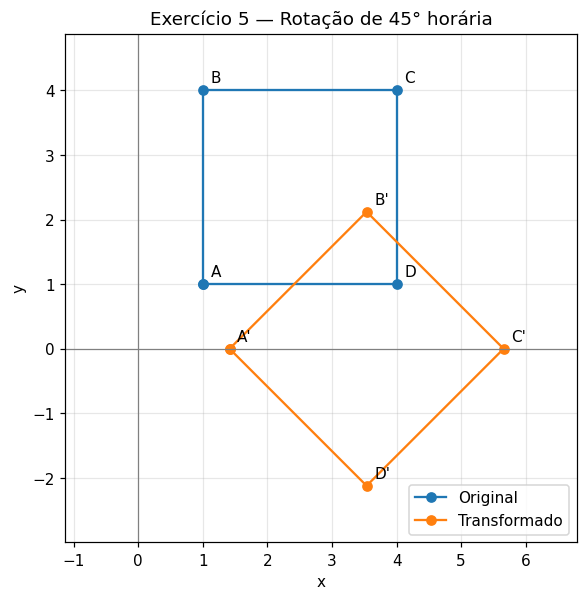

In [6]:
quadrado = np.array([[1, 1], [1, 4], [4, 4], [4, 1]])
angulo = np.deg2rad(-45)
rotacao = np.array([
    [np.cos(angulo), -np.sin(angulo)],
    [np.sin(angulo),  np.cos(angulo)],
])
quadrado_novo = quadrado @ rotacao.T

print("A', B', C', D' (uma linha por vértice):")
print(quadrado_novo)
plotar(quadrado, quadrado_novo, ['A', 'B', 'C', 'D'], 'Exercício 5 — Rotação de 45° horária')

**Resposta (aproximada):**

- A' ≈ **(1,4142; 0)**.
- B' ≈ **(3,5355; 2,1213)**.
- C' ≈ **(5,6569; 0)**.
- D' ≈ **(3,5355; −2,1213)**.

Os valores exatos são A' = (√2; 0), B' = (5√2/2; 3√2/2), C' = (4√2; 0) e D' = (5√2/2; −3√2/2).

## Exercício 6 — Reflexão simples

Dado o ponto P(2, 5), aplique uma reflexão em relação ao eixo y.

**Pergunta:** Qual é a nova posição de P'?

A reflexão em relação ao eixo y troca o sinal de x e mantém y: (x', y') = (−x, y).

P' = [-2  5]


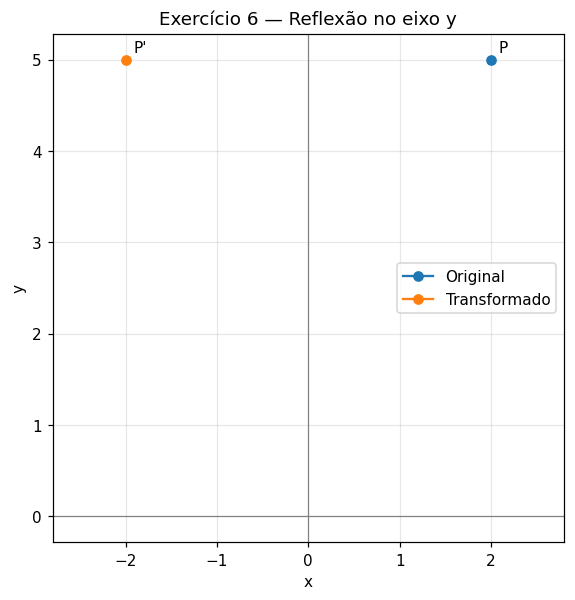

In [7]:
p = np.array([2, 5])
p_novo = p * np.array([-1, 1])

print("P' =", p_novo)
plotar([p], [p_novo], ['P'], 'Exercício 6 — Reflexão no eixo y')

**Resposta:** P' = **(−2, 5)**.

## Exercício 7 — Reflexão de um triângulo

Considere o triângulo A(2, 3), B(4, 3) e C(3, 5). Aplique uma reflexão em relação ao eixo x.

**Pergunta:** Quais são as novas coordenadas dos vértices?

A reflexão em relação ao eixo x mantém x e troca o sinal de y: (x', y') = (x, −y).

A', B', C' (uma linha por vértice):
[[ 2 -3]
 [ 4 -3]
 [ 3 -5]]


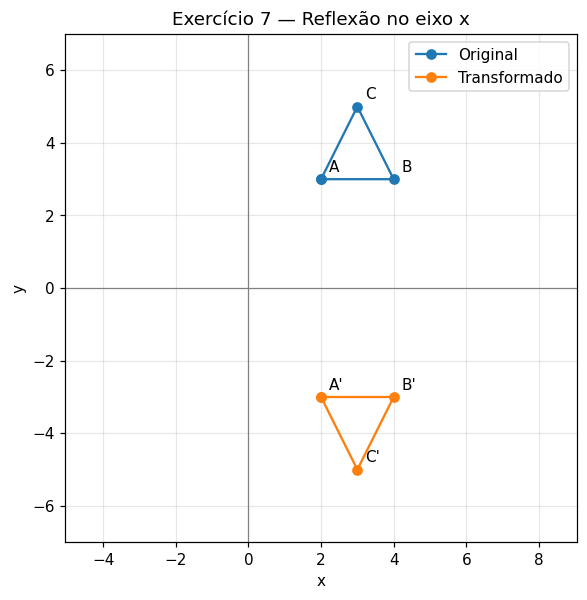

In [8]:
triangulo = np.array([[2, 3], [4, 3], [3, 5]])
triangulo_novo = triangulo * np.array([1, -1])

print("A', B', C' (uma linha por vértice):")
print(triangulo_novo)
plotar(triangulo, triangulo_novo, ['A', 'B', 'C'], 'Exercício 7 — Reflexão no eixo x')

**Resposta:** A' = **(2, −3)**, B' = **(4, −3)** e C' = **(3, −5)**.

## Exercício 8 — Cisalhamento horizontal

Dado o ponto P(2, 3), aplique um cisalhamento horizontal com k = 2.

**Pergunta:** Qual é a nova posição de P'?

No cisalhamento horizontal, x' = x + ky e y' = y.

P' = [8 3]


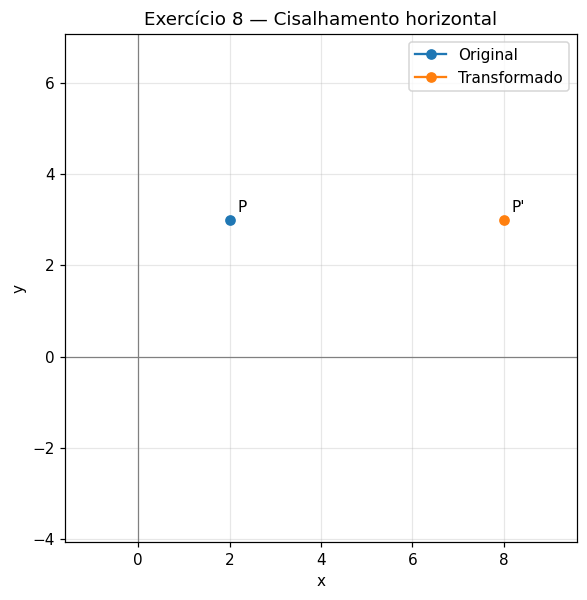

In [9]:
p = np.array([2, 3])
k = 2
p_novo = np.array([p[0] + k * p[1], p[1]])

print("P' =", p_novo)
plotar([p], [p_novo], ['P'], 'Exercício 8 — Cisalhamento horizontal')

**Resposta:** P' = **(8, 3)**, pois x' = 2 + 2 × 3 = 8 e y' = 3.

## Exercício 9 — Composição de transformações

Dado o ponto P(3, 2), aplique, nesta ordem:

1. Translação com vetor (1, −1).
2. Rotação de 90° no sentido anti-horário em torno da origem.
3. Escala uniforme de fator 2.

**Pergunta:** Qual é a nova posição de P' após todas as transformações?

Cada etapa usa o resultado da anterior. Para 90° anti-horários, podemos usar diretamente a matriz com valores 0, −1 e 1.

Após a translação: [4 1]
Após a rotação: [-1  4]
Após a escala (P'): [-2  8]


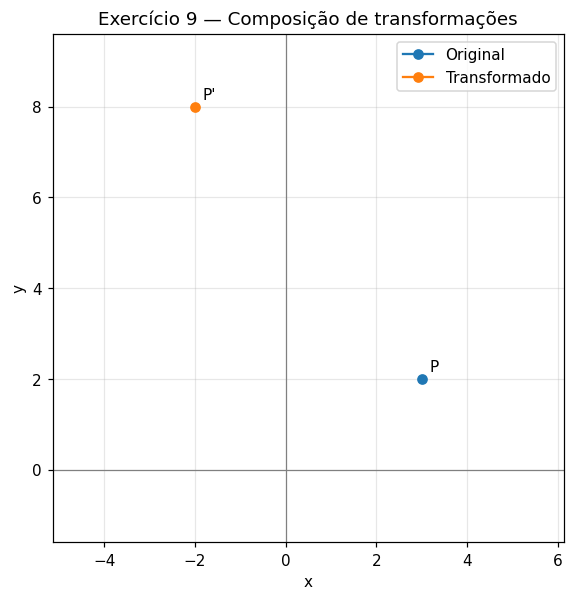

In [10]:
p = np.array([3, 2])
p_transladado = p + np.array([1, -1])
rotacao_90 = np.array([[0, -1], [1, 0]])
p_rotacionado = rotacao_90 @ p_transladado
p_final = p_rotacionado * 2

print('Após a translação:', p_transladado)
print('Após a rotação:', p_rotacionado)
print("Após a escala (P'):", p_final)
plotar([p], [p_final], ['P'], 'Exercício 9 — Composição de transformações')

**Resposta:** (3, 2) → (4, 1) → (−1, 4) → **(−2, 8)**.
Portanto, P' = **(−2, 8)**.

## Exercício 10 — Combinação de transformações em uma figura

Dado o retângulo A(1, 1), B(5, 1), C(5, 3) e D(1, 3), aplique, nesta ordem:

1. Translação com vetor (−2, 3).
2. Escala não uniforme com fator 1,5 em x e fator 0,5 em y.
3. Reflexão em relação ao eixo y.

**Pergunta:** Quais são as novas coordenadas dos vértices após as três transformações?

Em cada matriz, as linhas representam A, B, C e D.
Após a translação:
[[-1  4]
 [ 3  4]
 [ 3  6]
 [-1  6]]
Após a escala:
[[-1.5  2. ]
 [ 4.5  2. ]
 [ 4.5  3. ]
 [-1.5  3. ]]
Após a reflexão:
[[ 1.5  2. ]
 [-4.5  2. ]
 [-4.5  3. ]
 [ 1.5  3. ]]


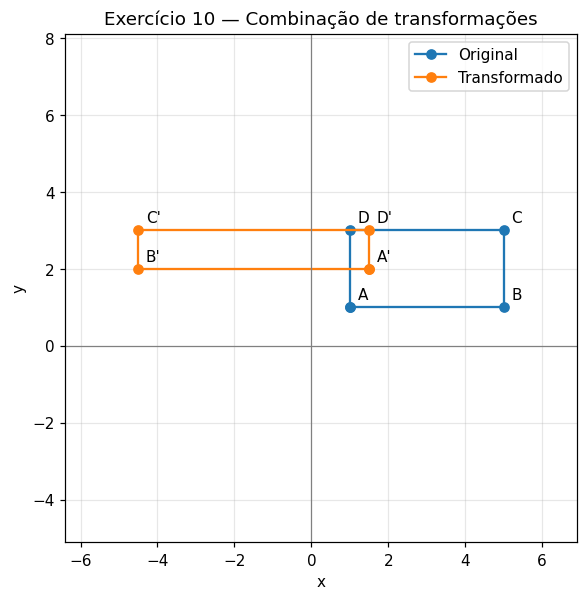

In [11]:
retangulo = np.array([[1, 1], [5, 1], [5, 3], [1, 3]])
transladado = retangulo + np.array([-2, 3])
escalado = transladado * np.array([1.5, 0.5])
refletido = escalado * np.array([-1, 1])

print('Em cada matriz, as linhas representam A, B, C e D.')
print('Após a translação:')
print(transladado)
print('Após a escala:')
print(escalado)
print('Após a reflexão:')
print(refletido)
plotar(retangulo, refletido, ['A', 'B', 'C', 'D'], 'Exercício 10 — Combinação de transformações')

**Resposta:**

| Vértice | Após a translação | Após a escala | Após a reflexão (resultado final) |
|---|---|---|---|
| A | (−1; 4) | (−1,5; 2) | **(1,5; 2)** |
| B | (3; 4) | (4,5; 2) | **(−4,5; 2)** |
| C | (3; 6) | (4,5; 3) | **(−4,5; 3)** |
| D | (−1; 6) | (−1,5; 3) | **(1,5; 3)** |